In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import pickle
import numpy as np
import os

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving yellow wallpaper.txt to yellow wallpaper.txt


In [ ]:
file = open("yellow wallpaper.txt", "r", encoding = "utf8")
# store file in list
lines = []
for i in file:
    lines.append(i)

# Convert list to string
data = ""
for i in lines:
  data = ' '. join(lines)

#replace unnecessary stuff with space
data = data.replace('\n', '').replace('\r', '').replace('\ufeff', '').replace('“','').replace('”','')  #new line, carriage return, unicode character --> replace by space

#remove unnecessary spaces
data = data.split()
data = ' '.join(data)
data[:500]

'The Yellow Wallpaper by Charlotte Perkins Gilman It is very seldom that mere ordinary people like John and myself secure ancestral halls for the summer. A colonial mansion, a hereditary estate, I would say a haunted house, and reach the height of romantic felicity, — but that would be asking too much of fate! Still I will proudly declare that there is something queer about it. Else, why should it be let so cheaply? And why have stood so long untenanted? John laughs at me, of course, but one expe'

In [ ]:
len(data)

31325

In [ ]:
import tensorflow as tf
import pickle
import numpy as np
import os
tokenizer = tf.keras.preprocessing.text.Tokenizer()
tokenizer.fit_on_texts([data])

# saving the tokenizer for predict function
pickle.dump(tokenizer, open('token.pkl', 'wb'))

sequence_data = tokenizer.texts_to_sequences([data])[0]
sequence_data[:15]

[3, 114, 536, 42, 537, 538, 539, 4, 7, 51, 540, 8, 541, 542, 160]

In [ ]:
len(sequence_data)

6249

In [ ]:
vocab_size = len(tokenizer.word_index) + 1
print(vocab_size)

1236


In [ ]:
sequences = []

for i in range(3, len(sequence_data)):
    words = sequence_data[i-3:i+1]
    sequences.append(words)

print("The Length of sequences are: ", len(sequences))
sequences = np.array(sequences)
sequences[:10]

The Length of sequences are:  6246


array([[  3, 114, 536,  42],
       [114, 536,  42, 537],
       [536,  42, 537, 538],
       [ 42, 537, 538, 539],
       [537, 538, 539,   4],
       [538, 539,   4,   7],
       [539,   4,   7,  51],
       [  4,   7,  51, 540],
       [  7,  51, 540,   8],
       [ 51, 540,   8, 541]])

In [ ]:
X = []
y = []

for i in sequences:
    X.append(i[0:3])
    y.append(i[3])

X = np.array(X)
y = np.array(y)

In [ ]:
print("Data: ", X[:10])
print("Response: ", y[:10])


Data:  [[  3 114 536]
 [114 536  42]
 [536  42 537]
 [ 42 537 538]
 [537 538 539]
 [538 539   4]
 [539   4   7]
 [  4   7  51]
 [  7  51 540]
 [ 51 540   8]]
Response:  [ 42 537 538 539   4   7  51 540   8 541]


In [ ]:
!pip install tensorflow
from tensorflow.keras.utils import to_categorical
y = to_categorical(y, num_classes=vocab_size)
y[:5]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
#BUILD THE MODEL
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
model = Sequential()
model.add(Embedding(vocab_size, 10))
model.add(LSTM(1000, return_sequences=True))
model.add(LSTM(1000))
model.add(Dense(1000, activation="relu"))
model.add(Dense(vocab_size, activation="softmax"))

In [ ]:
model.build(input_shape=(None,3))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 3, 10)          │        12,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 3, 1000)        │     4,044,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1000)           │     8,004,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1236)           │     1,237,236 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,298,596 (54.54 MB)

 Trainable params: 14,298,596 (54.54 MB)

 Non-trainable params: 0 (0.00 B)

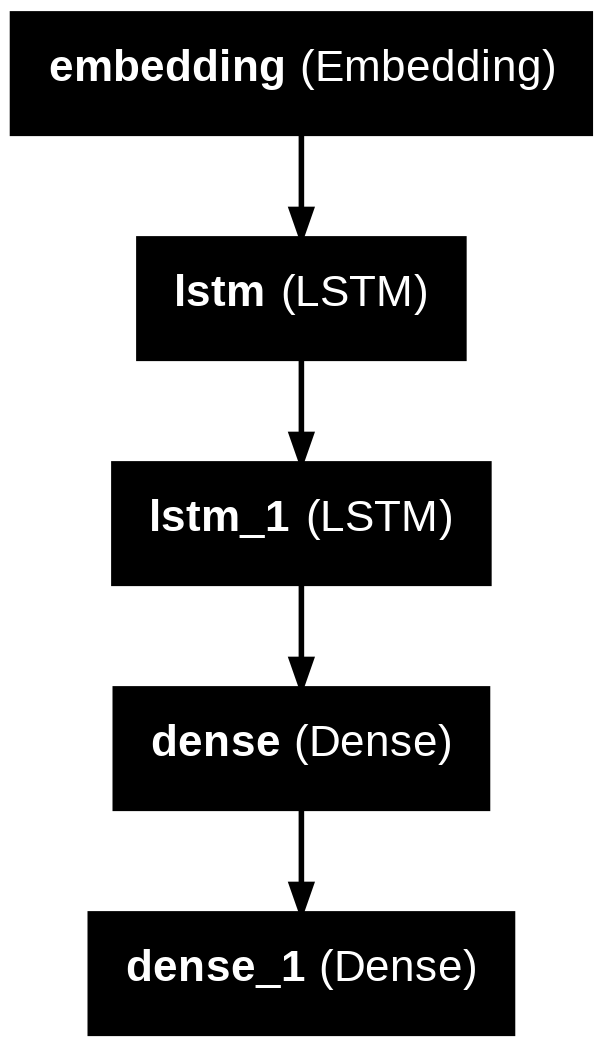

In [ ]:
#View of flow
from tensorflow import keras
from tensorflow.keras.utils import plot_model
tf.keras.utils.plot_model(model, to_file='plot.png', show_layer_names=True)

In [ ]:
# TRAIN THE MODEL
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Change the filepath to end with '.keras'
checkpoint = ModelCheckpoint("next_words.keras", monitor='loss', verbose=1, save_best_only=True)
model.compile(loss="categorical_crossentropy", optimizer=Adam(learning_rate=0.001))
model.fit(X, y, epochs=70, batch_size=64, callbacks=[checkpoint])

Epoch 1/70
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 6.4383
Epoch 1: loss improved from inf to 6.16933, saving model to next_words.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 6.4329
Epoch 2/70
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 5.8221
Epoch 2: loss improved from 6.16933 to 5.82122, saving model to next_words.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 5.8220
Epoch 3/70
96/98 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 5.7145
Epoch 3: loss improved from 5.82122 to 5.73795, saving model to next_words.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 5.7152
Epoch 4/70
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 5.5745
Epoch 4: loss improved from 5.73795 to 5.60426, saving model to next_words.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 5.5751
Epoch 5/70
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 5.3447
Epoch 5: loss improved from 5.60426 to 5.36111, saving model to next_words.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 5

In [ ]:
#FINAL PREDICTION
from tensorflow.keras.models import load_model
import numpy as np
import pickle

# Load the model and tokenizer
model = load_model('next_words.keras')
tokenizer = pickle.load(open('token.pkl', 'rb'))

def Predict_Next_Words(model, tokenizer, text):

  sequence = tokenizer.texts_to_sequences([text])
  sequence = np.array(sequence)
  preds = np.argmax(model.predict(sequence))
  predicted_word = ""

  for key, value in tokenizer.word_index.items():
      if value == preds:
          predicted_word = key
          break

  print(predicted_word)
  return predicted_word

In [ ]:
while True:
  text=input("Enter your line:")

  if text == "0":
      print("Execution completed.....")
      break

  else:
      try:
          text = text.split(" ")[:3]
          print("First three words:", text)

          Predict_Next_Words(model, tokenizer, text)

      except Exception as e:
        print("Error occurred: ",e)
        continue

In [ ]:
from google.colab import drive
drive.mount('/content/drive')